# 04 — Feature Engineering + Ablation + Kaggle Submission

**Phụ trách: Nguyễn Hoàng Long (Thành viên 4)** — theo [plan Lab03](../lab03_house_price_plan.md) mục 6–9.

Notebook này thực hiện các nhiệm vụ:

1. Tạo feature mới theo plan mục 7 (`src/features.py`).
2. Đánh giá từng feature — thêm từng feature một vào tập Original và đo ΔRMSE.
3. Chạy ablation study E0–E5 (plan mục 8) với Ridge, GradientBoosting (5-Fold CV) và MLP (holdout validation).
4. So sánh trước/sau feature engineering (E0 vs E5).
5. Tạo submission Kaggle (plan mục 9, `src/predict.py`).
6. Tổng hợp bảng kết quả cuối (plan mục 17).

**Metric:** RMSE trên `log1p(SalePrice)`, seed = 42. Ridge/GradientBoosting đánh giá bằng 5-Fold CV; MLP dùng holdout 80/20 giống Thành viên 3 — hai kiểu đánh giá để riêng, không trộn lẫn.

In [1]:
from pathlib import Path
import sys

# Cho phép chạy từ thư mục gốc project hoặc từ notebooks/
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from IPython.display import Image, display

from src.features import (
    ENGINEERED_FEATURES,
    FEATURE_GROUPS,
    ABLATION_EXPERIMENTS,
    add_features,
)
from src.run_ablation import (
    load_train,
    run_ablation,
    run_feature_evaluation,
    write_final_table,
    plot_ablation,
    plot_feature_evaluation,
    plot_before_after,
    RESULTS_DIR,
    FIGURES_DIR,
)

RANDOM_STATE = 42
print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = C:\Users\Hoang Long\Documents\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price


## 1. Tạo feature mới (plan mục 7)

Toàn bộ công thức nằm trong `src/features.py`:

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | Tổng diện tích sử dụng chính |
| `TotalBathrooms` | `FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath` | Số phòng tắm quy đổi |
| `TotalPorchSF` | `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + WoodDeckSF` | Tổng diện tích porch/sàn gỗ |
| `HouseAge` | `YrSold - YearBuilt` | Tuổi nhà lúc bán |
| `RemodAge` | `YrSold - YearRemodAdd` | Thời gian kể từ lần sửa chữa |
| `GarageAge` | `YrSold - GarageYrBlt` | Tuổi garage (NaN nếu không có garage) |
| `HasGarage/HasBsmt/HasFireplace/HasPool/Has2ndFloor` | giá trị > 0 -> 1 | Cờ nhị phân sự hiện diện |

Các feature chỉ dùng cột gốc, **không đụng target** nên không gây data leakage; preprocessing vẫn `fit` trên train của từng fold như bình thường.

In [2]:
display(pd.DataFrame([
    {"group": name, "features": ", ".join(feats)}
    for name, feats in FEATURE_GROUPS.items()
]))

display(pd.DataFrame([
    {"experiment": exp,
     "feature set": label,
     "features added": ", ".join(feats) if feats else "(none)"}
    for exp, (label, feats) in ABLATION_EXPERIMENTS.items()
]))

,group,features
0,totalsf,TotalSF
1,totalbathrooms,TotalBathrooms
2,totalporchsf,TotalPorchSF
3,age,"HouseAge, RemodAge, GarageAge"
4,binary,"HasGarage, HasBsmt, HasFireplace, HasPool, Has..."


,experiment,feature set,features added
0,E0,Original,(none)
1,E1,+ TotalSF,TotalSF
2,E2,+ TotalSF + TotalBathrooms,"TotalSF, TotalBathrooms"
3,E3,+ HouseAge + RemodAge,"HouseAge, RemodAge"
4,E4,+ Binary features,"HasGarage, HasBsmt, HasFireplace, HasPool, Has..."
5,E5,All engineered features,"TotalSF, TotalBathrooms, TotalPorchSF, HouseAg..."


In [3]:
X, y = load_train(PROJECT_ROOT)
X_e5 = add_features(X)  # None = toàn bộ feature
new_cols = [c for c in X_e5.columns if c not in X.columns]

print(f"Original: {X.shape[1]} cột -> Engineered: {X_e5.shape[1]} cột")
print("Feature mới:", new_cols)
display(X_e5[new_cols].head())
display(X_e5[new_cols].describe().round(2))
print("Số giá trị thiếu của từng feature mới:")
print(X_e5[new_cols].isna().sum().to_string())

Original: 79 cột -> Engineered: 90 cột
Feature mới: ['TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge', 'RemodAge', 'GarageAge', 'HasGarage', 'HasBsmt', 'HasFireplace', 'HasPool', 'Has2ndFloor']


,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,RemodAge,GarageAge,HasGarage,HasBsmt,HasFireplace,HasPool,Has2ndFloor
0,2566,3.5,61,5,5,5.0,1,1,0,0,1
1,2524,2.5,298,31,31,31.0,1,1,1,0,0
2,2706,3.5,42,7,6,7.0,1,1,1,0,1
3,2473,2.0,307,91,36,8.0,1,1,1,0,1
4,3343,3.5,276,8,8,8.0,1,1,1,0,1


,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,RemodAge,GarageAge,HasGarage,HasBsmt,HasFireplace,HasPool,Has2ndFloor
count,1460.00,1460.00,1460.00,1460.00,1460.00,1379.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,2567.05,2.21,181.33,36.55,22.95,29.31,0.94,0.97,0.53,0.00,0.43
std,821.71,0.79,156.66,30.25,20.64,24.73,0.23,0.16,0.50,0.07,0.50
min,334.00,1.00,0.00,0.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2009.50,2.00,45.00,8.00,4.00,6.00,1.00,1.00,0.00,0.00,0.00
50%,2474.00,2.00,164.00,35.00,14.00,28.00,1.00,1.00,1.00,0.00,0.00
75%,3004.00,2.50,266.00,54.00,41.00,47.00,1.00,1.00,1.00,0.00,1.00
max,11752.00,6.00,1027.00,136.00,60.00,107.00,1.00,1.00,1.00,1.00,1.00


Số giá trị thiếu của từng feature mới:
TotalSF            0
TotalBathrooms     0
TotalPorchSF       0
HouseAge           0
RemodAge           0
GarageAge         81
HasGarage          0
HasBsmt            0
HasFireplace       0
HasPool            0
Has2ndFloor        0


In [4]:
rows = []
for exp, (label, feats) in ABLATION_EXPERIMENTS.items():
    X_exp = add_features(X, features=feats) if feats else X
    rows.append({
        "experiment": exp,
        "feature set": label,
        "features": ", ".join(feats) if feats else "-",
        "n_columns": X_exp.shape[1],
    })
display(pd.DataFrame(rows))

,experiment,feature set,features,n_columns
0,E0,Original,-,79
1,E1,+ TotalSF,TotalSF,80
2,E2,+ TotalSF + TotalBathrooms,"TotalSF, TotalBathrooms",81
3,E3,+ HouseAge + RemodAge,"HouseAge, RemodAge",81
4,E4,+ Binary features,"HasGarage, HasBsmt, HasFireplace, HasPool, Has...",84
5,E5,All engineered features,"TotalSF, TotalBathrooms, TotalPorchSF, HouseAg...",90


## 2. Đánh giá từng feature

Mỗi feature được thêm **đơn lẻ** vào tập Original và đánh giá lại bằng 5-Fold CV (cùng siêu tham số Ridge/GradientBoosting đã tuning).

- `ΔRMSE < 0` (màu xanh): thêm feature này **giảm** RMSE → hữu ích.
- `ΔRMSE > 0` (màu đỏ): RMSE tăng lên → feature gây hại khi dùng riêng.

Kết quả lưu tại `outputs/results/feature_evaluation.csv`.

In [5]:
feature_eval, base_ridge, base_gb = run_feature_evaluation(PROJECT_ROOT)
print(f"Baseline E0 — Ridge CV RMSE: {base_ridge:.5f} | GradientBoosting CV RMSE: {base_gb:.5f}")
display(feature_eval)

# Vẽ và lưu biểu đồ đánh giá từng feature.
fig_path = plot_feature_evaluation(feature_eval, base_ridge, base_gb, FIGURES_DIR)
print("Đã lưu:", fig_path)

Baseline E0: Ridge=0.14655, GB=0.12915
  +TotalSF         Ridge=0.14670 (+0.00015) | GB=0.12792 (-0.00124)
  +TotalBathrooms  Ridge=0.14656 (+0.00001) | GB=0.12804 (-0.00111)
  +TotalPorchSF    Ridge=0.14653 (-0.00002) | GB=0.12832 (-0.00083)
  +HouseAge        Ridge=0.14660 (+0.00006) | GB=0.12983 (+0.00068)
  +RemodAge        Ridge=0.14656 (+0.00001) | GB=0.13006 (+0.00091)
  +GarageAge       Ridge=0.14655 (-0.00000) | GB=0.13017 (+0.00102)
  +HasGarage       Ridge=0.14687 (+0.00033) | GB=0.12961 (+0.00045)
  +HasBsmt         Ridge=0.14700 (+0.00045) | GB=0.12985 (+0.00070)
  +HasFireplace    Ridge=0.14615 (-0.00040) | GB=0.12909 (-0.00006)
  +HasPool         Ridge=0.14491 (-0.00164) | GB=0.12924 (+0.00008)
  +Has2ndFloor     Ridge=0.14656 (+0.00001) | GB=0.12883 (-0.00032)
Baseline E0 — Ridge CV RMSE: 0.14655 | GradientBoosting CV RMSE: 0.12915


,feature,ridge_cv_rmse,ridge_delta_vs_e0,gb_cv_rmse,gb_delta_vs_e0,gb_improves
0,TotalSF,0.14670,0.00015,0.12792,-0.00124,True
1,TotalBathrooms,0.14656,0.00001,0.12804,-0.00111,True
2,TotalPorchSF,0.14653,-0.00002,0.12832,-0.00083,True
3,Has2ndFloor,0.14656,0.00001,0.12883,-0.00032,True
4,HasFireplace,0.14615,-0.00040,0.12909,-0.00006,True
5,HasPool,0.14491,-0.00164,0.12924,0.00008,False
6,HasGarage,0.14687,0.00033,0.12961,0.00045,False
7,HouseAge,0.14660,0.00006,0.12983,0.00068,False
8,HasBsmt,0.14700,0.00045,0.12985,0.00070,False
9,RemodAge,0.14656,0.00001,0.13006,0.00091,False


Đã lưu: C:\Users\Hoang Long\Documents\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\figures\feature_evaluation.png


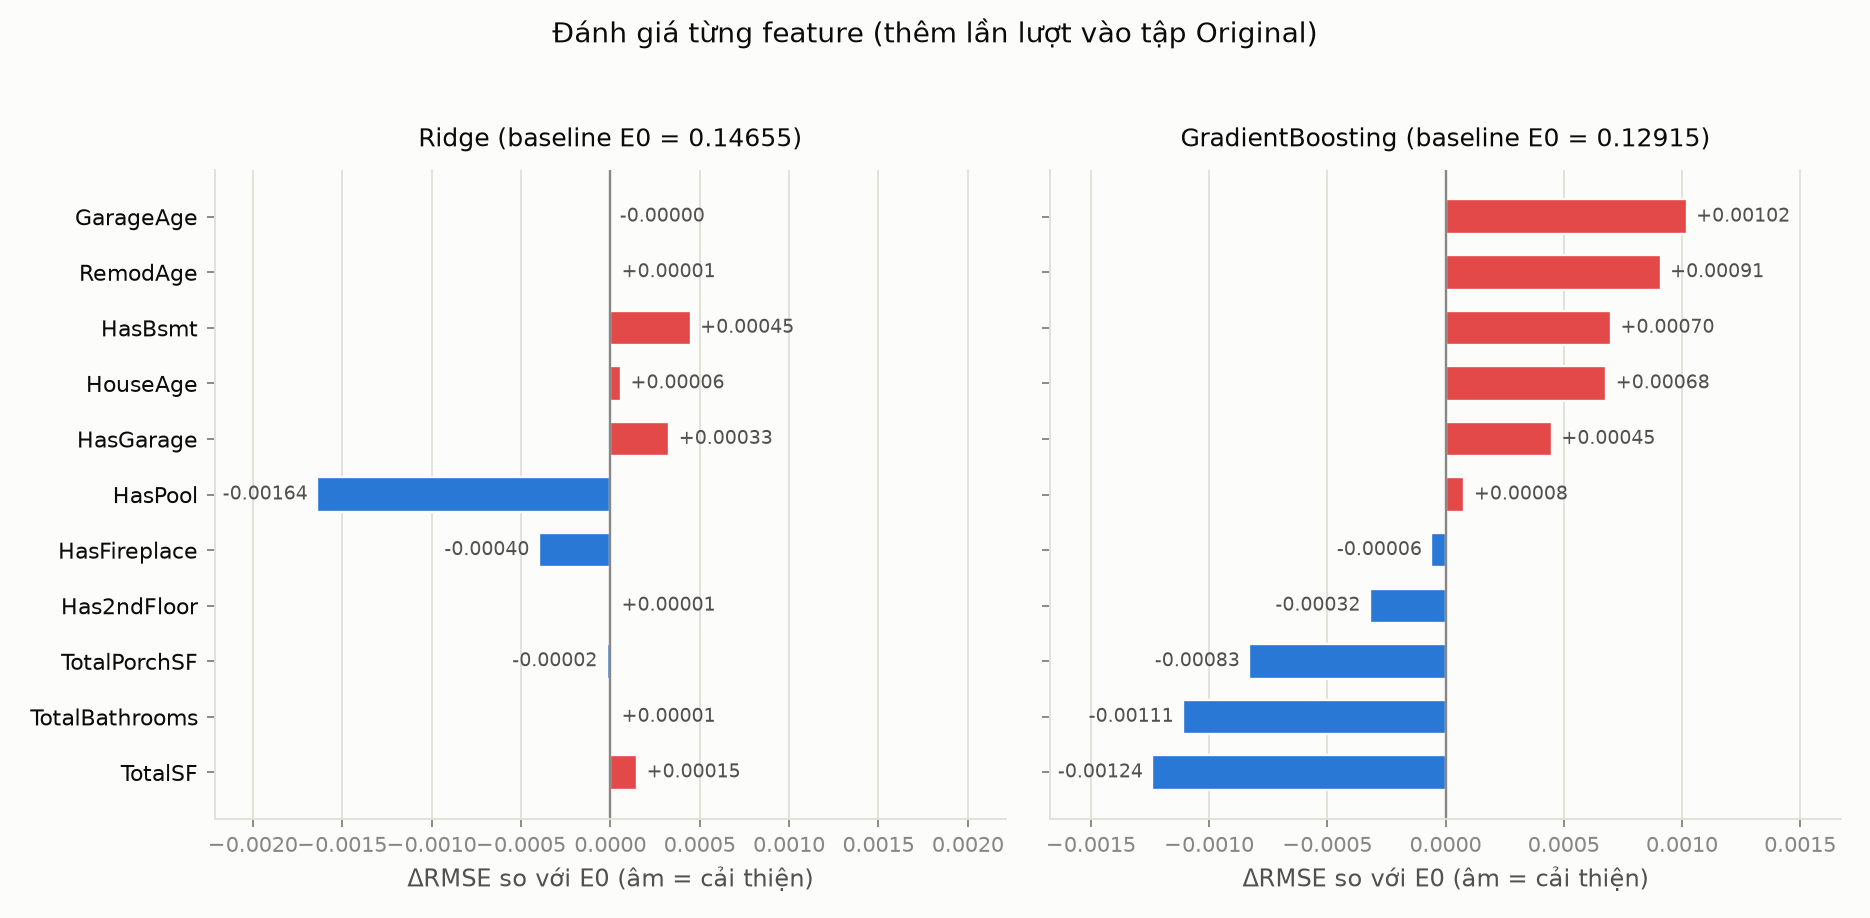

In [6]:
display(Image(filename=str(FIGURES_DIR / "feature_evaluation.png")))

In [7]:
best = feature_eval.iloc[0]
worst = feature_eval.iloc[-1]
n_improve = int(feature_eval["gb_improves"].sum())
print(f"Baseline E0 (GradientBoosting): {base_gb:.5f}")
print(f"Feature cải thiện tốt nhất khi dùng riêng: {best['feature']} "
      f"-> GB RMSE {best['gb_cv_rmse']:.5f} ({best['gb_delta_vs_e0']:+.5f})")
print(f"Feature tệ nhất khi dùng riêng: {worst['feature']} "
      f"-> GB RMSE {worst['gb_cv_rmse']:.5f} ({worst['gb_delta_vs_e0']:+.5f})")
print(f"{n_improve}/{len(feature_eval)} feature giảm RMSE của GradientBoosting khi thêm riêng lẻ.")

Baseline E0 (GradientBoosting): 0.12915
Feature cải thiện tốt nhất khi dùng riêng: TotalSF -> GB RMSE 0.12792 (-0.00124)
Feature tệ nhất khi dùng riêng: GarageAge -> GB RMSE 0.13017 (+0.00102)
5/11 feature giảm RMSE của GradientBoosting khi thêm riêng lẻ.


## 3. Ablation experiments E0–E5 (plan mục 8)

| Experiment | Features |
|---|---|
| E0 | Original |
| E1 | + TotalSF |
| E2 | + TotalSF + TotalBathrooms |
| E3 | + HouseAge + RemodAge |
| E4 | + Binary features |
| E5 | All engineered features |

- **Ridge / GradientBoosting**: 5-Fold CV RMSE, siêu tham số cố định bằng bảng tuning của Thành viên 2 (`alpha=30`; `n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8`).
- **MLP**: cấu hình tốt nhất của Thành viên 3 (`256-128-64`, lr `3e-4`, dropout `0.2`), validation RMSE trên cùng split 80/20 seed 42.

Kết quả lưu tại `outputs/results/ablation_results.csv`.

In [8]:
ablation = run_ablation(PROJECT_ROOT, with_mlp=True)
display(ablation[[
    "experiment", "feature_set", "n_raw_features",
    "ridge_cv_rmse", "gb_cv_rmse", "mlp_val_rmse",
    "ridge_delta_vs_e0", "gb_delta_vs_e0", "mlp_delta_vs_e0",
]])

# Vẽ biểu đồ ablation và trước/sau.
print("Đã lưu:", plot_ablation(ablation, FIGURES_DIR))
print("Đã lưu:", plot_before_after(ablation, FIGURES_DIR))

  MLP_E0: epoch=1, train RMSE=0.32893, val RMSE=0.36587, best=0.36587
  MLP_E0: epoch=50, train RMSE=0.05162, val RMSE=0.13365, best=0.12940
Finished MLP_E0: best epoch=22, RMSE=0.12940
[E0] Original: Ridge=0.14655, GB=0.12915, MLP=0.1294
  MLP_E1: epoch=1, train RMSE=0.32443, val RMSE=0.36403, best=0.36403
  MLP_E1: epoch=50, train RMSE=0.05162, val RMSE=0.13424, best=0.12971
Finished MLP_E1: best epoch=20, RMSE=0.12971
[E1] + TotalSF: Ridge=0.1467, GB=0.12792, MLP=0.12971
  MLP_E2: epoch=1, train RMSE=0.31870, val RMSE=0.35759, best=0.35759
  MLP_E2: epoch=50, train RMSE=0.05261, val RMSE=0.13155, best=0.12957
Finished MLP_E2: best epoch=20, RMSE=0.12957
[E2] + TotalSF + TotalBathrooms: Ridge=0.1467, GB=0.12822, MLP=0.12957
  MLP_E3: epoch=1, train RMSE=0.32437, val RMSE=0.36365, best=0.36365
  MLP_E3: epoch=50, train RMSE=0.05210, val RMSE=0.13384, best=0.13170
Finished MLP_E3: best epoch=20, RMSE=0.13170
[E3] + HouseAge + RemodAge: Ridge=0.14662, GB=0.12939, MLP=0.1317
  MLP_E4: ep

,experiment,feature_set,n_raw_features,ridge_cv_rmse,gb_cv_rmse,mlp_val_rmse,ridge_delta_vs_e0,gb_delta_vs_e0,mlp_delta_vs_e0
0,E0,Original,79,0.14655,0.12915,0.12940,0.00000,0.00000,0.00000
1,E1,+ TotalSF,80,0.14670,0.12792,0.12971,0.00015,-0.00123,0.00031
2,E2,+ TotalSF + TotalBathrooms,81,0.14670,0.12822,0.12957,0.00015,-0.00093,0.00017
3,E3,+ HouseAge + RemodAge,81,0.14662,0.12939,0.13170,0.00007,0.00024,0.00230
4,E4,+ Binary features,84,0.14528,0.12964,0.13105,-0.00127,0.00049,0.00165
5,E5,All engineered features,90,0.14549,0.12645,0.13189,-0.00106,-0.00270,0.00249


Đã lưu: C:\Users\Hoang Long\Documents\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\figures\ablation_comparison.png
Đã lưu: C:\Users\Hoang Long\Documents\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\figures\before_after_feature_engineering.png


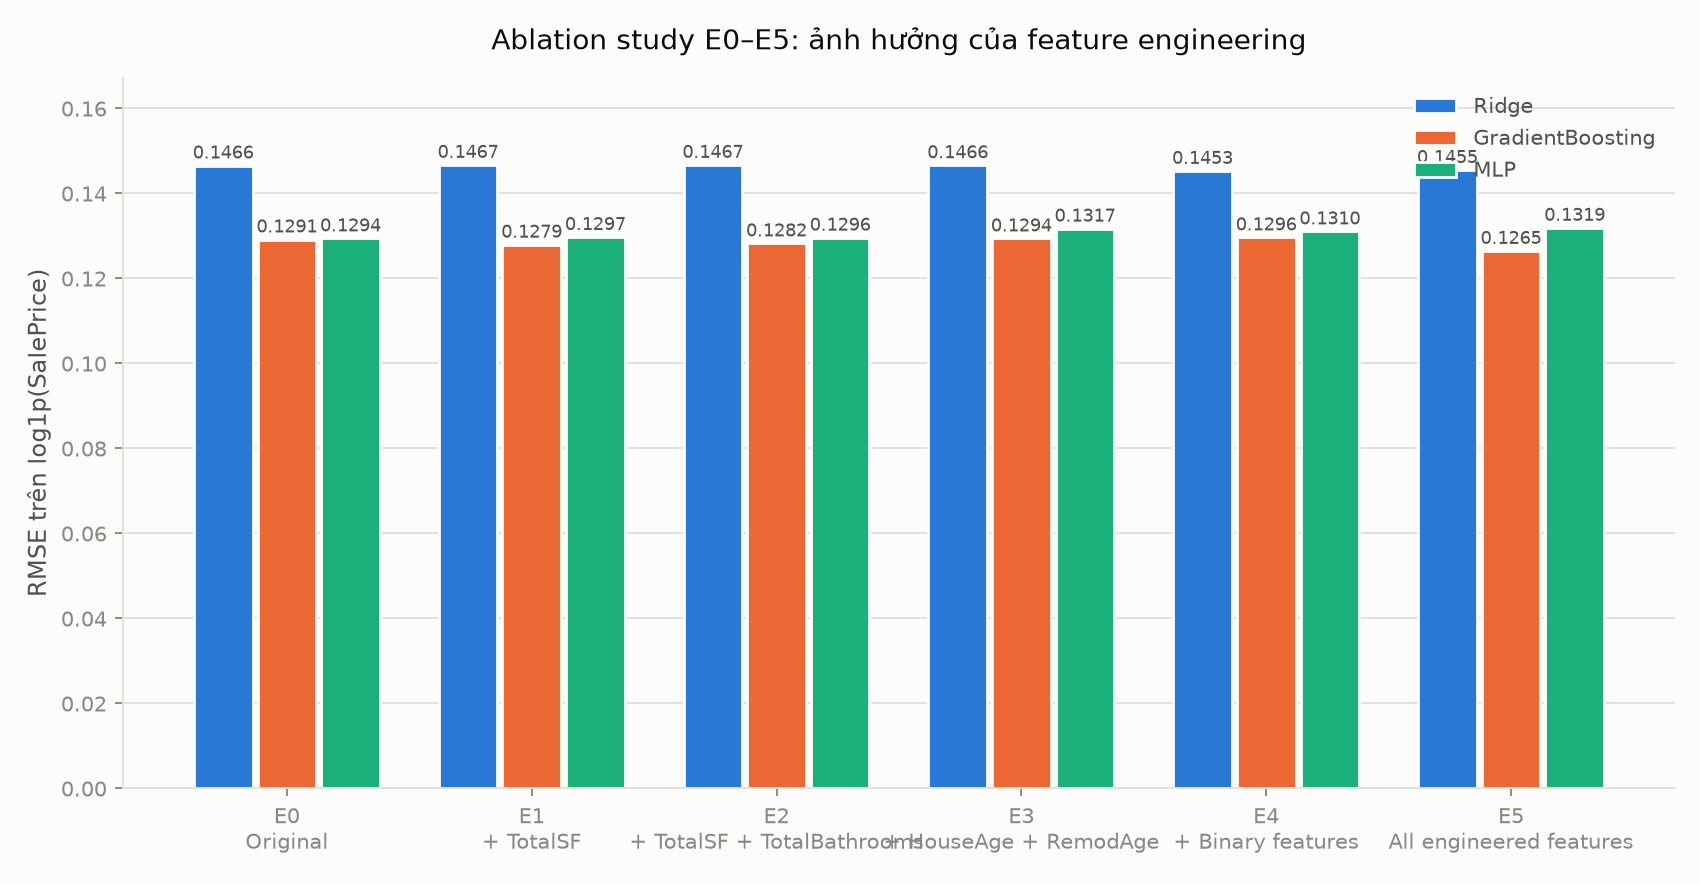

In [9]:
display(Image(filename=str(FIGURES_DIR / "ablation_comparison.png")))

In [10]:
# Nhận xét bằng số liệu theo đúng mẫu plan mục 8 (không viết "feature tốt" chung chung).
e0 = ablation[ablation["experiment"] == "E0"].iloc[0]
for exp in ["E1", "E2", "E3", "E4", "E5"]:
    row = ablation[ablation["experiment"] == exp].iloc[0]
    print(f"[{exp}] {row['feature_set']}")
    print(f"    Ridge : {e0['ridge_cv_rmse']:.5f} -> {row['ridge_cv_rmse']:.5f} "
          f"({row['ridge_delta_vs_e0']:+.5f})")
    print(f"    GB    : {e0['gb_cv_rmse']:.5f} -> {row['gb_cv_rmse']:.5f} "
          f"({row['gb_delta_vs_e0']:+.5f})")
    if "mlp_val_rmse" in ablation.columns:
        print(f"    MLP   : {e0['mlp_val_rmse']:.5f} -> {row['mlp_val_rmse']:.5f} "
              f"({row['mlp_delta_vs_e0']:+.5f})")

[E1] + TotalSF
    Ridge : 0.14655 -> 0.14670 (+0.00015)
    GB    : 0.12915 -> 0.12792 (-0.00123)
    MLP   : 0.12940 -> 0.12971 (+0.00031)
[E2] + TotalSF + TotalBathrooms
    Ridge : 0.14655 -> 0.14670 (+0.00015)
    GB    : 0.12915 -> 0.12822 (-0.00093)
    MLP   : 0.12940 -> 0.12957 (+0.00017)
[E3] + HouseAge + RemodAge
    Ridge : 0.14655 -> 0.14662 (+0.00007)
    GB    : 0.12915 -> 0.12939 (+0.00024)
    MLP   : 0.12940 -> 0.13170 (+0.00230)
[E4] + Binary features
    Ridge : 0.14655 -> 0.14528 (-0.00127)
    GB    : 0.12915 -> 0.12964 (+0.00049)
    MLP   : 0.12940 -> 0.13105 (+0.00165)
[E5] All engineered features
    Ridge : 0.14655 -> 0.14549 (-0.00106)
    GB    : 0.12915 -> 0.12645 (-0.00270)
    MLP   : 0.12940 -> 0.13189 (+0.00249)


## 4. So sánh trước/sau feature engineering (E0 vs E5)

Bảng dưới đây là số liệu gốc cần đưa vào báo cáo — điền thêm % cải thiện = `(E0 - E5) / E0 * 100`.

,Model,Feature set,CV/Val RMSE,Evaluation,Cải thiện (%)
0,Ridge,Original (E0),0.14655,5-Fold CV,NaN
1,Ridge,Engineered (E5),0.14549,5-Fold CV,0.72
2,GradientBoosting,Original (E0),0.12915,5-Fold CV,NaN
3,GradientBoosting,Engineered (E5),0.12645,5-Fold CV,2.09
4,MLP,Original (E0),0.12940,Holdout val,NaN
5,MLP,Engineered (E5),0.13189,Holdout val,-1.92


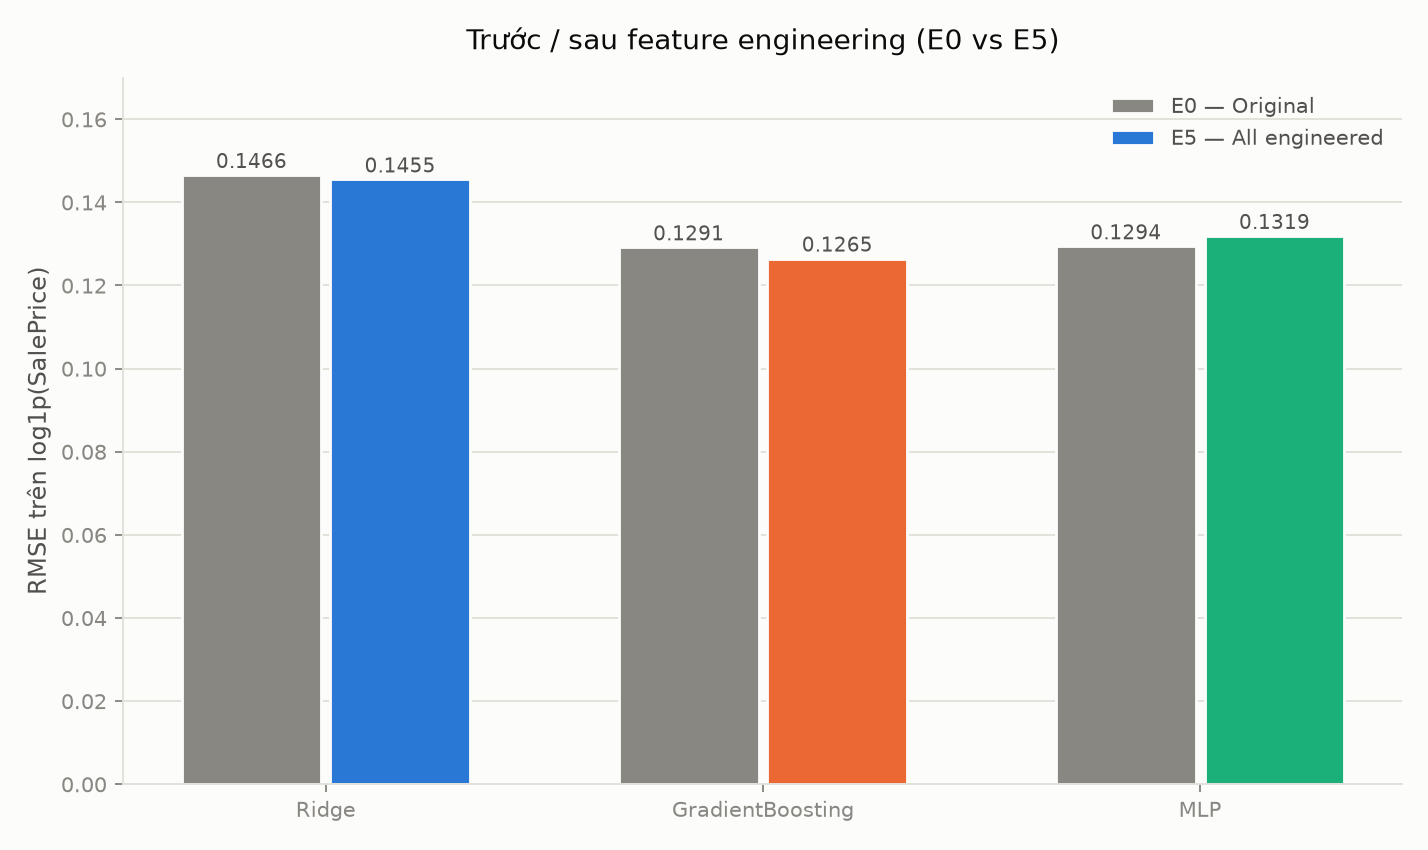

In [11]:
e0 = ablation[ablation["experiment"] == "E0"].iloc[0]
e5 = ablation[ablation["experiment"] == "E5"].iloc[0]

comparison = pd.DataFrame([
    {"Model": "Ridge",
     "Feature set": "Original (E0)", "CV/Val RMSE": e0["ridge_cv_rmse"], "Evaluation": "5-Fold CV"},
    {"Model": "Ridge",
     "Feature set": "Engineered (E5)", "CV/Val RMSE": e5["ridge_cv_rmse"], "Evaluation": "5-Fold CV"},
    {"Model": "GradientBoosting",
     "Feature set": "Original (E0)", "CV/Val RMSE": e0["gb_cv_rmse"], "Evaluation": "5-Fold CV"},
    {"Model": "GradientBoosting",
     "Feature set": "Engineered (E5)", "CV/Val RMSE": e5["gb_cv_rmse"], "Evaluation": "5-Fold CV"},
    {"Model": "MLP",
     "Feature set": "Original (E0)", "CV/Val RMSE": e0["mlp_val_rmse"], "Evaluation": "Holdout val"},
    {"Model": "MLP",
     "Feature set": "Engineered (E5)", "CV/Val RMSE": e5["mlp_val_rmse"], "Evaluation": "Holdout val"},
])
comparison["Cải thiện (%)"] = np.nan
for model, col in [("Ridge", "ridge_cv_rmse"),
                   ("GradientBoosting", "gb_cv_rmse"),
                   ("MLP", "mlp_val_rmse")]:
    mask = comparison["Model"] == model
    comparison.loc[mask & (comparison["Feature set"] == "Engineered (E5)"), "Cải thiện (%)"] = round(
        (e0[col] - e5[col]) / e0[col] * 100, 2)
display(comparison)

display(Image(filename=str(FIGURES_DIR / "before_after_feature_engineering.png")))

## 5. Tạo submission Kaggle (plan mục 9)

- `submission_sklearn.csv`: best model sklearn của Thành viên 2 (đã fit trên toàn train, feature Original).
- `submission_best.csv`: model có CV RMSE tốt nhất trong ablation E0–E5, huấn luyện lại trên toàn bộ 1460 dòng train với feature set tương ứng.
- `submission_mlp.csv`: do Thành viên 3 tạo (`src/predict_mlp.py`).

Điểm Kaggle sẽ được ghi vào `outputs/results/submission_log.json` sau khi nhóm nộp lên Kaggle (không điền số giả định).

In [12]:
from src.predict import create_all

sklearn_path, best_path, best_info = create_all(PROJECT_ROOT)
print("Thông tin submission_best:", best_info)

Saved 1459 predictions: C:\Users\Hoang Long\Documents\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\submissions\submission_sklearn.csv
Best from ablation: GradientBoosting / E5 (CV RMSE=0.12645)
Saved 1459 predictions: C:\Users\Hoang Long\Documents\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\submissions\submission_best.csv
Updated C:\Users\Hoang Long\Documents\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\results\submission_log.json
Thông tin submission_best: {'model': 'GradientBoosting', 'experiment': 'E5', 'cv_rmse': 0.12645}


In [13]:
sample = pd.read_csv(PROJECT_ROOT / "data" / "sample_submission.csv")
for path in [sklearn_path, best_path,
             PROJECT_ROOT / "outputs" / "submissions" / "submission_mlp.csv"]:
    if not path.exists():
        print(f"[missing] {path.name}")
        continue
    sub = pd.read_csv(path)
    assert list(sub.columns) == ["Id", "SalePrice"], path
    assert len(sub) == len(sample) and np.array_equal(sub["Id"], sample["Id"]), path
    assert np.isfinite(sub["SalePrice"]).all() and (sub["SalePrice"] > 0).all(), path
    print(f"[ok] {path.name}: {len(sub)} dòng, "
          f"giá trung bình {sub['SalePrice'].mean():,.0f}, "
          f"min {sub['SalePrice'].min():,.0f}, max {sub['SalePrice'].max():,.0f}")

display(pd.read_csv(best_path).head())

[ok] submission_sklearn.csv: 1459 dòng, giá trung bình 177,471, min 36,721, max 545,447
[ok] submission_best.csv: 1459 dòng, giá trung bình 177,550, min 38,635, max 609,730
[ok] submission_mlp.csv: 1459 dòng, giá trung bình 181,252, min 47,448, max 676,409


,Id,SalePrice
0,1461,124351.680108
1,1462,161528.978715
2,1463,184022.155223
3,1464,189804.239229
4,1465,181729.183485


## 6. Bảng kết quả cuối (plan mục 17)

Gộp kết quả Thành viên 2 (sklearn), Thành viên 3 (MLP) và ablation của Thành viên 4 vào `outputs/results/experiment_results.csv`. Cột `Kaggle Score` để trống cho tới khi nộp file lên Kaggle.

In [14]:
final_table = write_final_table(PROJECT_ROOT)
display(final_table)

,Model,Feature Set,CV/Val RMSE,Std,Evaluation,Source,Kaggle Score
0,GradientBoosting (Tuned),Original,0.12915,0.02309,5-Fold CV,outputs/results/sklearn_results.csv,
1,RandomForest,Original,0.14523,0.01921,5-Fold CV,outputs/results/sklearn_results.csv,
2,Ridge,Original,0.14678,0.03933,5-Fold CV,outputs/results/sklearn_results.csv,
3,MLP (MLP_2_lr_3e-4),Original,0.12940,,Holdout validation 80/20,outputs/results/mlp_results.csv,
4,Ridge,Engineered (E5),0.14549,0.04078,5-Fold CV,outputs/results/ablation_results.csv,
5,GradientBoosting (Tuned),Engineered (E5),0.12645,0.01814,5-Fold CV,outputs/results/ablation_results.csv,
6,MLP (best config),Engineered (E5),0.13189,,Holdout validation 80/20,outputs/results/ablation_results.csv,


## Kết luận

- Các file kết quả:
  - `outputs/results/feature_evaluation.csv` — đánh giá từng feature.
  - `outputs/results/ablation_results.csv` — ablation E0–E5.
  - `outputs/results/ablation_summary.json` — cấu hình thực nghiệm.
  - `outputs/results/experiment_results.csv` — bảng tổng hợp cuối.
  - `outputs/submissions/submission_sklearn.csv`, `submission_best.csv` — file nộp Kaggle.
  - `outputs/figures/feature_evaluation.png`, `ablation_comparison.png`, `before_after_feature_engineering.png`.
- Nhận xét chi tiết về việc feature nào cải thiện bao nhiêu được lấy trực tiếp từ các bảng ở mục 2–4 (điền số vào báo cáo, không viết cảm tính).
- Sau khi nộp file lên Kaggle, ghi score vào `outputs/results/submission_log.json` và cột `Kaggle Score` của `experiment_results.csv`.